### Análise Estatística de Dados com NumPy Para a Área de Marketing

1. Uma plataforma de e-commerce coleta um volume significativo de dados sobre a interação do usuários com o site, incluíndo o número de visitas, a duração da sessão, a atividade de adição de produtos ao carrinho e os valores de compra finalizados. No entanto, esses dados estão sempre subutilizados. Atualmente, as decisões sobre campanhas de marketing, promoções e molhorias na experiência do usuário (UX) são tomadas com base em intuições e métricas de alto nível, sem uma compreensão profunda dos dados de comportamento que impulsionam os resultados.

**1.2. Problema de Negócio**

A empresa enfrenta o desafio de compreender profundamente os padrões de comportamento que diferenciam os clientes de alto valor dos visitantes que abandonam o site sem comprar. Essa felta de clareza resulta em:

 - Marketing Genérico: Nossas campanhas de marketing são de tamanho único, resultando em baixo engajamento e desperdício de orçamento, pois não personalizar as ofertaspara os segmentos de clientes corretos.

 - Perda de oportunidads: Não conseguimos identificar e engajar proativamente os cliente com maior potencial de compra ou criar estratégias para converter os visitantes que demonstram interesse, mas não finalizam a compra.

 - Decisões não embasadas: As estratégias de produto e de experiência do usuário carecem uma base quantitativa sólida sobre quais comportamentos (ex: tempo no site, frequência de visitas) estão mais fortemente correlacionados com o sucesso das vendas.

**1.3. Objetivo Principal**

Utilizar a análise estatística dos dados de navegação e compra para segmentar clientes, identificar os principais indicadores de comportamento que levem à conversão e fornecer insights acionáveis para a equipe de marketing e produtos, a fim de aumentar o ticket médio
e a taxa de conversão geral da plataforma.

**1.4. Perguntas-chave a serem respondidas**

A análise de dados deve responder as seguintes perguntas críticas de negócio:

  - 1 - Qual é o perfil médio do nosso usuário em termos de visitas, tempo de navegação e valor de compra (ticket médio)
    
  - 2 - Quais são as características e comportamentos distintos dos nossos clientes de alto valor? Eles visitam mais o site? Passam mais tempo navegando?

    
  - 3 - Qual o comportamento dos usuários que visitam o site, mas não realizam nenhuma compra? Onde está a oportunidade de conversão com este grupo?

    
  - 4 - Existe um correlação estatísticamente relevante entre o tempo gasto no site, o número de itens no carrinho e o valor final da compra?


**1.5. Resultado esperado e impacto do negócio**

O resultado deste projeto será um relatório de análise estatística que permitirá:

  - Segmentação aprimorada: Criação de pelo menos dois segmentos de clientes (Ex: "Cliente de alto valor" e "Visitantes engajados sem compra") para direcionamento de companhas de marketing personalizadas.

  - Otimização de marketing: Direcionar o orçamento de marketing para ações nos comportamentos que mais re correlacionam com compra de alto valor, aumentando o retorno sobre o investimento (ROI).

  - Melhoria da experincia de usuário (ux): Fornecer à equipe de produto dados que possam justificar testes a/b ou melhorias em área do site frequentadas por usuários que não convertem.

In [1]:
!pip install -q -U watermark

In [2]:
%pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

In [4]:
import numpy as np

In [5]:
import matplotlib.pyplot as plt

In [26]:
import seaborn as sns

In [6]:
# Definir uma semente para reprodutibilidade dos resultados
np.random.seed(42)

In [7]:
%reload_ext watermark
%watermark -a "Leonardo da Silva Neves"

Author: Leonardo da Silva Neves



In [8]:
%watermark --iversion

matplotlib: 3.10.8
numpy     : 2.3.5
pandas    : 2.3.3



**3. Função para gerar dados fictícios**

Vamos criar um conjunto de dados para quinhentos usuários. Cada usuário terá quatro métricas associadas descritas abaixo.

 - visitas: Número de vezes que o usuário visitou o site no mês.
 - tempo_no_site: Tempo total em minutos que o usuário passou no site.
 - itens_no_carinho: Número de itens que o usuário adicionou ao carrinho.
 - valor_compra: O valor total em R$ da compra realizada pelo usuário no mês.

In [9]:
# Definir o número de usuários
num_usuarios = 500

In [10]:
# 1. Gerar o número de visitas entre 1 e 50
visitas = np.random.randint(1, 51, size = num_usuarios)

**Distribuição Normal**

A distribuição normal é um tipo de distribuição de probabilidade contínua, simétrica em torno da média, com formato característico de sino. Nesse tipo de distribuição os valores próximos da média são mais frequêntes e a probabilidade de observar valores extremos diminui gradualmente conforme se afasta do centro. É definida por dois parâmetros: a média (que indica o centro da distribuição) e o desvio padrâo (que indica a dispersão dos dados). É muito usado em estatística e ciência dos dados porque muitos fenômenos naturais e sociais tendem a seguir esse padrão.

In [11]:
# 2. Gerar o tempo do site (distribuição normal, correlacionando com as visitas)
# Média de 20 minutos, desvio padrão de 5, com bônus por visita
tempo_no_site = np.random.normal(loc=20, scale=5, size = num_usuarios) + (visitas * 0.5)
tempo_no_site = np.round(tempo_no_site, 2) # Arredondar para 2 casas decimais

In [12]:
# 3. Gerar número de itens no carrinho (dependente das visitas e do tempo))
# Usuários que visitam mais e passam mais tempo, tendem a adicionar mais itens
itens_no_carrinho = np.random.randint(0, 8, size = num_usuarios) + (visitas // 10)

In [13]:
# Garante que o tempo no site também influencie positivamente
itens_no_carrinho = (itens_no_carrinho + (tempo_no_site // 15)).astype(int)

In [14]:
# 4. Gerar o valor da compra (correlacionado com os itens no carrinho)
# Preço médio por item de R$ 35, com alguma variação aleatória
valor_compra = (itens_no_carrinho * 35) + np.random.normal(loc = 0, scale = 10, size = num_usuarios)

In [15]:
# Se não houver item no carrinho, o valor deve ser zero
valor_compra[itens_no_carrinho == 0] = 0
valor_compra[valor_compra < 0] = 0 # Corrigir valor negativo que possam surgir
valor_compra = np.round(valor_compra, 2)

In [16]:
# Unindo tudo em uma únicac matriz (ndarray)
# Cada linha representa um número, cada coluna uma métrica
dados_ecommerce = np.column_stack((visitas, tempo_no_site, itens_no_carrinho, valor_compra))

In [17]:
print("\nShape da massa de dados:", dados_ecommerce.shape)
print("\nExemplos dos 5 primeiros usuários (linhas:")
print("\nColunas: [Visitas, Tempo no Site (min), Itens no Carrinho, Valor da Compra (R$)]\n")
print(dados_ecommerce[:5])


Shape da massa de dados: (500, 4)

Exemplos dos 5 primeiros usuários (linhas:

Colunas: [Visitas, Tempo no Site (min), Itens no Carrinho, Valor da Compra (R$)]

[[ 39.    23.29   9.   314.54]
 [ 29.    29.38   5.   177.43]
 [ 15.    26.24   6.   207.59]
 [ 43.    35.26   8.   283.52]
 [  8.    32.16   3.    92.48]]


**4. Análise Estatística Descritiva**

Agora que temos os dados, vamos calcular as principais métricas estatísticas para cada coluna para tem uma visão geral do comportamento dos nossos usuários.

 - A média é a soma de todas os valores dividido pela quantidade de elementos. Ela indica o valor "central" ou típico de um conjuto de dados.
 - A mediana é o valor que fica exatamente no meio quando os valores estão ordenados. Se houver número par de valores, é a média dos dois valores centrais. Ela é menos sensível a valores extremos do que a média.
 - O desvio padrão mede o quanto os valores se afastam, em média, da média do conjunto. Um desvio padrão alto significa qua os dados são mais mais espalhados; um baixo indica que estão mais próximos da média.

**Pergunta 1**

Qual é o pergil médio do nosso usuário em termos de visita, tempo de navegação e valor de compra (ticket médio)?

In [18]:
# Separar as colunas para facilitar a leitura do código
visitas_col = dados_ecommerce[:,0]
tempo_col = dados_ecommerce[:,1]
itens_col = dados_ecommerce[:,2]
valor_col = dados_ecommerce[:,3]

print("--- ANÁLISE ESTATÍSTICA GERAL ---")

# Média

media_visitas = np.mean(visitas_col)
media_tempo = np.mean(tempo_col)
media_itens = np.mean(itens_col)
media_valor = np.mean(valor_col)

print(f"\nMédia de visitas: {media_visitas:.2f}")
print(f"Média de Tempo no Site: {media_tempo:.2f} min")
print(f"Média de Itens no Carrinho: {media_itens:.2f}")
print(f"Média de Valor de Compra (Ticket Médio): R$ {media_valor:.2f}")

# Mediana (valor central, menos sensível a outliers)
mediana_valor = np.median(valor_col)
print(f"\nMediana do Valor de Compra: R$ {mediana_valor:.2f}")

# Desvio Padrão (mede a dispersão dos dados)
std_valor = np.std(valor_col)
print(f"Desvio Padrão do Valor de Compra: R$ {std_valor:.2f}")

# Valor Máximo e Mínimos
max_valor = np.max(valor_col)
min_valor_positivo = np.min(valor_col[valor_col > 0]) # Mínimo apenas entre quem comprou
print(f"Maior Valor de Compra: R$ {max_valor:.2f}")
print(f"Menor Valor de Compra (de quem comprou): R$ {min_valor_positivo:.2f}")

--- ANÁLISE ESTATÍSTICA GERAL ---

Média de visitas: 25.86
Média de Tempo no Site: 32.78 min
Média de Itens no Carrinho: 7.20
Média de Valor de Compra (Ticket Médio): R$ 252.70

Mediana do Valor de Compra: R$ 248.13
Desvio Padrão do Valor de Compra: R$ 106.94
Maior Valor de Compra: R$ 530.37
Menor Valor de Compra (de quem comprou): R$ 23.42


O gráfico abaixo mostra o histograma dos valores de compra com linhas verticais indicando a média (vermelho), a mediana(laranja) e o intervalo de um desvio padrão acima e abaixo da média (linhas verdes). Isso facilia análise de como os dados estão distribuídos e se existem possiveiis outliers ou assimetrias.

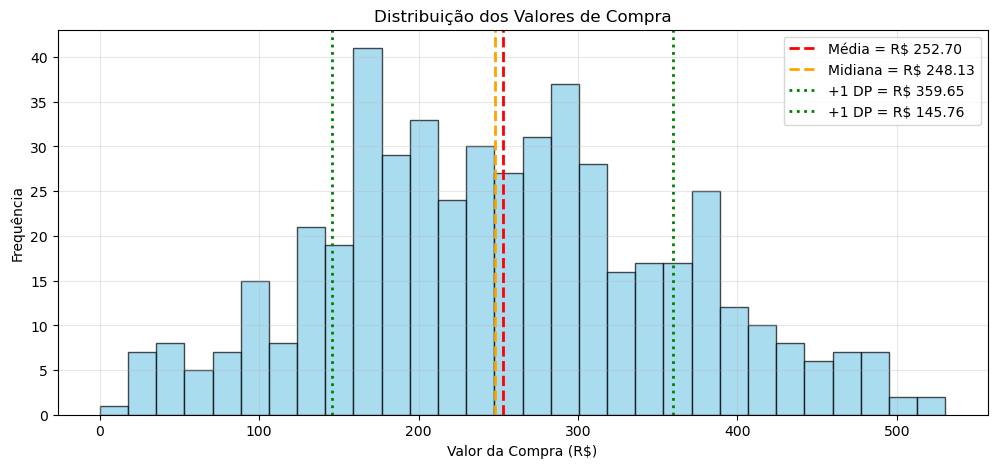

In [19]:
# Separando colunas

visitas_col = dados_ecommerce[:,0]
tempo_col = dados_ecommerce[:,1]
itens_col = dados_ecommerce[:,2]
valor_col = dados_ecommerce[:,3]

# Calculando as Estatísticas
media_valor = np.mean(valor_col)
mediana_valor = np.median(valor_col)
std_valor = np.std(valor_col)

# --- Gráfico ---
plt.figure(figsize=(12,5))
plt.hist(valor_col, bins=30, color= 'skyblue', edgecolor = 'black', alpha = 0.7)
plt.axvline(media_valor, color = 'red', linestyle = '--', linewidth = 2, label = f'Média = R$ {media_valor:.2f}')
plt.axvline(mediana_valor, color = 'orange', linestyle = '--', linewidth = 2, label = f'Midiana = R$ {mediana_valor:.2f}')
plt.axvline(media_valor + std_valor, color = 'green', linestyle = ':', linewidth = 2, label = f'+1 DP = R$ {media_valor + std_valor:.2f}')
plt.axvline(media_valor - std_valor, color = 'green', linestyle = ':', linewidth = 2, label = f'+1 DP = R$ {media_valor - std_valor:.2f}')
plt.title("Distribuição dos Valores de Compra")
plt.xlabel("Valor da Compra (R$)")
plt.ylabel('Frequência')
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

**Resposta da pergunta 1:**

O usuário acessa o site, em média, cerca de 26 vezes por mês, permanece em média 33 minutos navegando, adiciona aproximadamente 7 ao carrinho e realiza compras com ticket médio de R$ 252,70.

O gasto típico fica próximo da mediana de R$ 248,13.

Mas há grande variação entre clientes, alguns compram valores baixo a partir de R$ 23,42

Enquando outro chegam a gastar até 530,37

**5. Segmentação e Análise de Clientes**

Quais são as características se comportamentos distintos dos nossos clientes de "Alto-valor"? Eles visitam mais o site? Passam mais tempo navegando?

In [22]:
# Filtro booleano para clientes com compra > R$250
clientes_alto_valor = dados_ecommerce[dados_ecommerce[:,3] > 250]

print("\n--- ANÁLISE: CLIENTES DE ALTO VALOR (Compra > R$250) ---\n")
print(f"Número de clientes de alto valor: {clientes_alto_valor.shape[0]}")

# Estatísticas deste segmento
media_visitas_alto_valor = np.mean(clientes_alto_valor[:,0])
media_tempo_alto_valor = np.mean(clientes_alto_valor[:,1])

print(f"Média de visitas desses clientes: {media_visitas_alto_valor:.2f}")
print(f"Média de tempo no site desses cliente: {media_tempo_alto_valor:.2f}")


--- ANÁLISE: CLIENTES DE ALTO VALOR (Compra > R$250) ---

Número de clientes de alto valor: 245
Média de visitas desses clientes: 33.29
Média de tempo no site desses cliente: 37.11


**Resposta da Pergunta 2**

Os clientes de alto valor (aqueles que gastam mais de R$250) visitam o site com mair frequência, em média 33 vezes por mês, e permanecem mais tempo navegando, cerca de 37 minutos por sessão. Esse comportamento indica um alto nível de engajamento, sugerindo que quanto mais esses usuários interagem com a plataforma, maior tende a ser o valor de suas compras.

**Pergunta 3**

Qual o comportamento dos usuários que visitam o site, mas não realizam nenhuma compra? Onde está a oportunidade de conversão com este grupo?

In [ ]:
# Filtro para visitantes que não compram
visitantes_sem_compra = dados_ecommerce[dados_ecommerce[:,3] == 0]

print("\n--- ANÁLISE: VISITANTES QUE NÃO COMPRAM ---\n")
print(f"Número de visitantes que não compraram: {visitantes_sem_compra.shape[0]}")

# Estatística deste segmento
media_tempo_sem_compra = np.mean(visitantes_sem_compra[:,1])
media_visitas_sem_compra = np.mean(visitantes_sem_compra[:,0])

print(f"Média de visita desses visitantes: {media_visitas_sem_compra:.2f}")
print(f"Apesar de não comprarem, eles passam em média {media_tempo_sem_compra:.2f}")

**Resposta da pergunta 3**

Os usuário que não realizam compras visitam o site em média 7 vezes e permanecem cerca de 15 minutos navegando, mas não finalizam nenhuma transação. Esse comportamento mostra que, mesmo com algum nível de interesse, eles acabam desistindo antes da compra, representando uma oportunidade para ações de remarketing, otimização do checkout e estratégias de incentivo, como descontos ou frete grátis, para aumentar a conversão.

**Análise de Correlação**

Vamos investigar a relação entre as diferentes variáveis. Uma matriz de correlação nos mostra como as veriáveis se movem juntas.

 - +1: Correlação positiva perfeita
 - -1: Correlação negativa perfeita
 - 0: nenhuma correlação linear

**Pergunta 4**

Existe uma correlação estatisticamente relavante entre o tempo gasto no site, o número de itens no carrinho e o valor final da compra?

In [23]:
# A função np.coocoef calcula a matriz de correlação
# rowvar=False indica que as colunas são as variáveis
matriz_correlação = np.corrcoef(dados_ecommerce, rowvar = False)

print("\n---MATRIZ DE CORRELAÇÃO ---\n")
print("[Visitas, Tempo, Itens, Valor]\n")
print(np.round(matriz_correlação, 2))


---MATRIZ DE CORRELAÇÃO ---

[Visitas, Tempo, Itens, Valor]

[[1.   0.83 0.65 0.65]
 [0.83 1.   0.6  0.59]
 [0.65 0.6  1.   1.  ]
 [0.65 0.59 1.   1.  ]]


Vamos melhorar a visualização colocando a matriz de correlação e forma gráfica

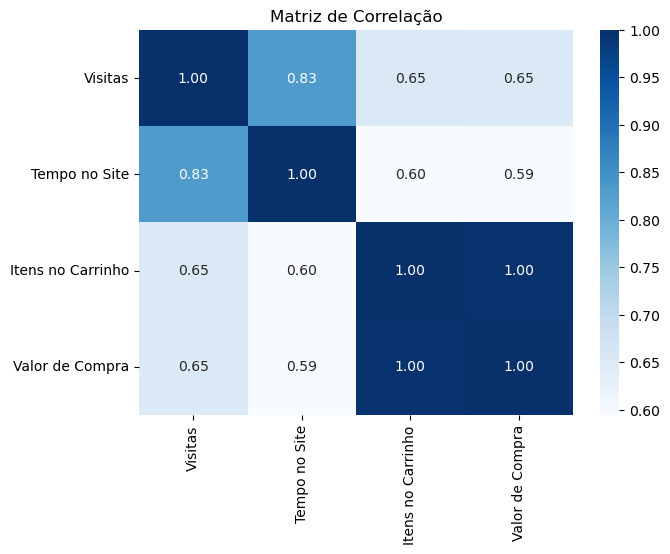

In [28]:
# Calcula a matriz de correlação
matriz_correlacao = np.corrcoef(dados_ecommerce, rowvar = False)

# Define os nomes das variáveis
nomes_variaveis = ["Visitas", "Tempo no Site", "Itens no Carrinho", "Valor de Compra"]

# Converter em DataFrame para exibir com rótulos
df_correlacao = pd.DataFrame(matriz_correlacao,
                             index = nomes_variaveis,
                             columns = nomes_variaveis)

# Matriz de correlação (mapa de calor)
plt.figure(figsize=(7, 5))
sns.heatmap(df_correlacao, annot = True, cmap = "Blues", fmt = ".2f")
plt.title("Matriz de Correlação")
plt.show()

In [29]:
df_correlacao

,Visitas,Tempo no Site,Itens no Carrinho,Valor de Compra
Visitas,1.000000,0.831550,0.652212,0.650696
Tempo no Site,0.831550,1.000000,0.596197,0.594764
Itens no Carrinho,0.652212,0.596197,1.000000,0.995665
Valor de Compra,0.650696,0.594764,0.995665,1.000000


**Resposta da pergunta 4:**

A matriz esta organizada na ordem [Visitas, Tempo, Itens, Valor]. Os valores variam entre -1 e +1, onde:

 - +1 indica correlação positiva perfeita
 -  0 indidca ausência de correlação
 - -1 indica correlação positiva perfeita

No trecho relevante para a pergunta:

 - Tempo <-> Valor = 0.59 -> correlação positiva moderada
 - Itens <-> Valor = 1.00 -> correlação positiva perfeita (neste conjuto de dados, valor cresce proporcionalmente ao número de itens)
 - Tempo <-> Itens = 0.60 -> correlação positiva moderada

Esses números indicam que quanto mais tempo o usuário passa no site, maior tende a ser o número de itens no carrinho e, consequentemente, maior o valor da compra. O fato de "Itens <-> Valor" ser 1.00 mostra que, no dataset analisado, o valor final cresce linearmente com a quantidade de itens (positivamente porque cada iten tem preço médio semelhante).

Assim, a resposta para a pergunta seria:

 - Sim. Há uma correlação estatísticamente relevante: o tempo gasto no site se relaciona moderadamente tanto com o número de itens no carrinho quanto com o valor final de compra, e a quantidade de itens tem correlação praticamente perfeita com o valor final, indicando forte relação entre esses fatores.

Obs: Para confirmar a significância estatística, seria necessário calcular o p-valor dessas correlações.

Nota: Correlação não implica causalidade. Não é porque uma variável tem correlação com outra, que uma variável está causando a outra. Para investigar a causa teríamos que fazer uma Análise Causal.

### Relatório Final, Conclusões e Insights a Partir dos Dados

Análise estatística dos dados de navegação e compra dos usuários do e-commerce permitiu compreender melhor o comportamento dos clientes e identificar padrões diretamente relacionados à geração de receita.

**1. Perfil Geral dos Usuários**

Os usuários acessam a plataforma em média 25,88 vezes por mês, permanecendo cerca de 32,78 minutos no site por sessão. Cada cliente adiciona, em média, 7.20 itens ao carrinho e realiza compras com ticket médio de R$ 252,70. A mediana do valor gasto é R$ 248,42 indicando que metade dos clientes compra abaixo e metade acima desse valor. Observou-se uma dispersão considerável nos gastos (desvio padrão de R$ 106,94), com compras variando de R$ 23,42 (mínimo entre compradores) a R$ 530,37 (máximo registro).

Esses números mostram que existe um grupo expressivo de consumidores que gastão significativamente mais que a média, mas também há grande variação no comportamento de compra.

**2. Clientes de Alto Valor**

Ao analisar os cliente que gastão mais que R$250, identificou-se um total de 245 usuários, representando aproximadamente metade da base analisada. Este grupo se destaca por visitar mais vezes o site (33,29 visitas em média) e permanecer por mais tempo (37,11 minutos), comparado ao perfil geral.

Isso sugere que engajamento elevado, tanto em frequência de visitas quanto em tempo de navegação, está fortemente associado a compras de maior valor. Esse clientes podem ser considerados um segmento prioritário para ações de fidelização, programas de recompensa e campanhas personalizadas.

**3. Visitantes Que Não Compram**

Foi identificado apenas 1 usuário que navega pelo site sem realizar compras. Apesar representar um cado isolado, ele visita em média 7 vezes e permanece 14,71 minutos no site. Esse comportamento, mesmo pouco expressivo aqui, ilustra a importância de monitorar usuários engajados que não convertem, pois podem representar oportunidades para companhas de remarketing, melhorias no processo de checkout ou incentivos específicos para concluir a compra.

** 4. Relações Entre Comportamentos e Receita**

A Matriz de correlação revelou que:

 - Itens no carrinho <-> Valor de compra = 1.00 -> correlação positiva perfeita; cada item adicional impacto diretamente o valor gasto.
 - Tempo no site <-> Itens no carrinho = 0.60 -> correlação moderada; usuários que permanecem mais tempo tendem a adicionar mais itens.
 - Tempo no site <-> Valor de compra = 0.59 -> correlação moderada; quanto mais tempo no site, maior tende a ser a compra.
 - Visitas <-> Valor de compora = 0.69 -> correlação positiva; maior frequência de acessos também contrubui para comprar maiores.

Esses resultados confirmam que  o engajamento do usuário (tempo e visitas) influencia a construção do carrinho e, consequentimente, o valor final da compra. Embora seja necessário confirmar a significância estatística com testes adicionais (p-valor), a força da correlação já orienta  decisões estratégicas.

**Conclusõe e Recomendações**

 - Segmentação estratégica: os clientes de alto valor apresentam comportamenteo diferenciado, com maior frequência e tempo de navegação. Esse grupo deve ser alvo de campanhas personalisadas e programas de fidelidade para aumentar a retenção e ticket médio.

 - Incentivo à construção de carrinho: como a quantidade de itens é fator determinante no valor gasto, estratégias como recomendações personalizadas, descontos progressivos e combos podem elevar o ticket médio.

 - Aproveitamento de visitantes engajados sem compra: embora pouco representativo aqui, vale investir em remarketing e otimização de UX para reduzir fricções no ckeckout e converter quem demonstra interesse.

 - Base quantitativa para decisões: a análise estatística mostra que dados simples (visitas, tempo, itens) já oferecem insights poderosos para melhorar campanhas de marketing e decisões de produto, substituindo ações baseadas apenas em intuição.


### Fim